# 问题二：滤后水浊度 FILT. NTU 动态时滞模型

本 notebook 严格对应 A 题第二问：

> 滤后水浊度（`FILT. NTU`）是衡量混凝、沉淀、过滤效果的核心指标，主要受原水浊度（`R/W NTU`）、原水 pH（`R/W PH`）、矾投加量（`ALUM`、`F/RIDE`）、原水流量（`R/W FLOW`）等因素影响，且存在明显时间滞后。  
> 要求建立动态数学模型，描述这些输入变量如何影响 `FILT. NTU`，并给出输入变量的时滞参数；对模型进行参数估计与验证，提供 RMSE、R² 等拟合精度。

本 notebook 的完整流程是：

```text
读取 merged.xlsx
↓
构造 DATETIME 与 OP_DATE
↓
清洗核心变量
↓
R/W PUMP DUTY 转换为 R/W PUMP COUNT（可选辅助变量）
↓
构造 lag0-lag12
↓
基于训练期相关性选择每个变量的最佳时滞
↓
构造 selected-lag 动态建模数据
↓
时间顺序 train/test split
↓
训练 Ridge / GAM / Random Forest / XGBoost
↓
输出 RMSE、R²、MAE
↓
输出参数估计、特征重要性、GAM effect curves
```

本 notebook 默认只使用原题明确要求的核心变量：

```text
R/W NTU
R/W PH
ALUM
F/RIDE
R/W FLOW
```

如果需要加入辅助变量，可以在参数区打开：

```python
INCLUDE_AUXILIARY_FEATURES = True
```


## 1. 导入依赖库

这一部分导入数据处理、建模、评价指标、可视化和文件保存所需的库。  
如果当前环境没有安装 `xgboost`，notebook 会自动跳过 XGBoost，不影响其他模型运行。


In [1]:
from pathlib import Path
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, SplineTransformer

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = e

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

print("依赖库导入完成。")
print("XGBoost 是否可用：", XGBOOST_AVAILABLE)


依赖库导入完成。
XGBoost 是否可用： True


## 2. 参数设置

这里设置第二问的目标变量、候选输入变量、最大滞后阶数、训练集比例和输出目录。

数据每 2 小时记录一次，因此：

```text
lag0  = 当前时刻
lag1  = 2 小时前
lag2  = 4 小时前
...
lag12 = 24 小时前
```

第二问原题的核心变量是：

```text
R/W NTU, R/W PH, ALUM, F/RIDE, R/W FLOW
```


In [2]:
# =========================
# 基础设置
# =========================

TARGET_COL = "FILT. NTU"
TARGET_NAME = "target_FILT_NTU"

# 0-12 阶滞后，每阶代表 2 小时
MAX_LAG = 12

# 按时间顺序划分训练集和测试集
TRAIN_RATIO = 0.80
RANDOM_STATE = 42

# 原题核心输入变量
CORE_FEATURES = [
    "R/W NTU",
    "R/W PH",
    "ALUM",
    "F/RIDE",
    "R/W FLOW",
]

# 可选辅助变量
# 注意：辅助变量不是原题第二问最核心要求，默认关闭。
AUXILIARY_FEATURES = [
    "RIVER LEVEL",
    "R/W CLR",
    "R/W PUMP COUNT",
]

INCLUDE_AUXILIARY_FEATURES = False

# F/RIDE 缺失值是否填 0
# 原数据中 F/RIDE 缺失较多，填 0 可以理解为未记录/未投加状态的简化处理。
FILL_FRIDE_MISSING_WITH_ZERO = True

# 是否对 FILT. NTU 做 clipping
# 第二问默认不做 clipping，避免改变目标变量含义。
CLIP_TARGET = False
TARGET_CLIP_UPPER = 2.0

# 输出目录
OUTPUT_DIR_NAME = "problem2"

# 模型参数
N_ESTIMATORS_RF = 500
N_ESTIMATORS_XGB = 500

print("参数设置完成。")


参数设置完成。


## 3. 自动定位 `merged.xlsx`

第二问应从原始合并数据 `merged.xlsx` 出发，而不是使用问题一的 selected-lag 文件。  
本函数会自动在当前目录、上级目录和项目 `data/` 文件夹中寻找 `merged.xlsx`。


In [3]:
def locate_merged_file(filename="merged.xlsx"):
    """
    自动寻找 merged.xlsx。
    兼容从项目根目录运行和从 codes/ 文件夹运行两种情况。
    """
    cwd = Path.cwd().resolve()
    candidates = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []
    for path in candidates:
        path = path.resolve()
        if path not in seen:
            seen.add(path)
            unique_candidates.append(path)

    for path in unique_candidates:
        if path.exists():
            return path

    for path in cwd.rglob(filename):
        return path.resolve()

    searched = "\n".join(str(path) for path in unique_candidates)
    raise FileNotFoundError(f"未找到 {filename}。已检查路径：\n{searched}")


DATA_PATH = locate_merged_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes
使用数据文件： E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
输出目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2


## 4. 读取原始合并数据

这里读取 `merged.xlsx`，并检查原始列名。  
第二问后续只使用与 `FILT. NTU` 动态模型相关的变量。


In [4]:
df = pd.read_excel(DATA_PATH)

print("原始数据规模：", df.shape)
print("原始列名：")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"未找到第二问目标变量 {TARGET_COL}。请检查 merged.xlsx 的列名。")

display(df.head())


原始数据规模： (5460, 18)
原始列名：
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']


,DATE,TIME,RIVER LEVEL,R/W PUMP DUTY,R/W FLOW,R/W NTU,R/W CLR,R/W PH,FILT. NTU,C/W WELL LEVEL,PH,NTU,CLR,CL2,F/RIDE,ALUM,T/W PUMP DUTY,T/W FLOW
0,2025-01-01,07:00:00,6.22,1.0,45.3,150,850.0,7.0,0.04,3.82,7.2,0.12,5.0,1.5,0.0,0.04,2.0,42.6
1,2025-01-01,09:00:00,6.34,1.0,45.2,120,830.0,7.0,0.05,3.81,7.2,0.12,5.0,1.5,0.0,0.04,2.0,42.6
2,2025-01-01,11:00:00,6.17,1.0,44.9,82,780.0,7.0,0.05,3.81,7.2,0.12,5.0,1.6,0.0,0.04,2.0,42.7
3,2025-01-01,13:00:00,5.99,1.0,44.9,62,720.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,0.0,0.04,2.0,42.3
4,2025-01-01,15:00:00,5.83,1.0,44.5,56,641.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,0.0,0.04,2.0,42.5


## 5. 构造时间列 `DATETIME` 和运行日 `OP_DATE`

原数据通常包含 `DATE` 和 `TIME` 两列。这里将其合成为 `DATETIME`。

同时构造运行日 `OP_DATE`：

```text
07:00, 09:00, ..., 23:00, 次日 01:00, 03:00, 05:00
```

归为同一个运行日。


In [5]:
def construct_datetime(data):
    data = data.copy()

    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data

    date_candidates = ["DATE", "Date", "date"]
    time_candidates = ["TIME", "Time", "time"]

    date_col = next((c for c in date_candidates if c in data.columns), None)
    time_col = next((c for c in time_candidates if c in data.columns), None)

    if date_col is None or time_col is None:
        raise ValueError("无法构造 DATETIME：需要 DATE 和 TIME 两列，或已有 DATETIME 列。")

    time_text = data[time_col].astype(str).str.split().str[-1]
    date_text = data[date_col].astype(str).str.split().str[0]

    data["DATETIME"] = pd.to_datetime(
        date_text + " " + time_text,
        errors="coerce"
    )

    return data


df = construct_datetime(df)

# 排序
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

# 构造 OP_DATE
df["OP_DATE"] = df["DATETIME"].dt.date
mask_before_7 = df["DATETIME"].dt.hour < 7
df.loc[mask_before_7, "OP_DATE"] = (
    df.loc[mask_before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

print("时间范围：", df["DATETIME"].min(), "至", df["DATETIME"].max())
print("DATETIME 缺失数：", df["DATETIME"].isna().sum())

display(df[["DATETIME", "OP_DATE", TARGET_COL]].head(15))


时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00
DATETIME 缺失数： 0


,DATETIME,OP_DATE,FILT. NTU
0,2025-01-01 07:00:00,2025-01-01,0.04
1,2025-01-01 09:00:00,2025-01-01,0.05
2,2025-01-01 11:00:00,2025-01-01,0.05
3,2025-01-01 13:00:00,2025-01-01,0.05
4,2025-01-01 15:00:00,2025-01-01,0.05
5,2025-01-01 17:00:00,2025-01-01,0.06
6,2025-01-01 19:00:00,2025-01-01,0.05
7,2025-01-01 21:00:00,2025-01-01,0.05
8,2025-01-01 23:00:00,2025-01-01,0.05
9,2025-01-02 01:00:00,2025-01-01,0.05


## 6. 第二问核心变量清洗

这里对目标变量和候选输入变量进行数值化处理。  
如果启用 `FILL_FRIDE_MISSING_WITH_ZERO`，则将 `F/RIDE` 缺失值填为 0。

第二问默认候选输入变量：

```text
R/W NTU
R/W PH
ALUM
F/RIDE
R/W FLOW
```


In [6]:
# 确定第二问实际使用的候选变量
candidate_features = CORE_FEATURES.copy()

if INCLUDE_AUXILIARY_FEATURES:
    candidate_features += AUXILIARY_FEATURES

# 只保留数据中实际存在的列
missing_candidates = [col for col in candidate_features if col not in df.columns]
candidate_features = [col for col in candidate_features if col in df.columns]

print("第二问使用的候选输入变量：")
print(candidate_features)

if len(missing_candidates) > 0:
    print("\n以下候选变量在数据中不存在，已自动跳过：")
    print(missing_candidates)

if len(candidate_features) == 0:
    raise ValueError("没有可用的第二问候选输入变量。")

# 数值化目标和输入
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

for col in candidate_features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# F/RIDE 缺失填 0
if FILL_FRIDE_MISSING_WITH_ZERO and "F/RIDE" in df.columns:
    before = df["F/RIDE"].isna().sum()
    df["F/RIDE"] = df["F/RIDE"].fillna(0)
    after = df["F/RIDE"].isna().sum()

    print(f"F/RIDE 缺失填 0：before={before}, after={after}")

# 可选目标 clipping
if CLIP_TARGET:
    before_above = int((df[TARGET_COL] > TARGET_CLIP_UPPER).sum())
    max_before = df[TARGET_COL].max(skipna=True)

    df[TARGET_COL] = df[TARGET_COL].clip(upper=TARGET_CLIP_UPPER)

    after_above = int((df[TARGET_COL] > TARGET_CLIP_UPPER).sum())
    max_after = df[TARGET_COL].max(skipna=True)

    print("目标变量 clipping 已启用：")
    print({
        "count_above_before": before_above,
        "max_before": max_before,
        "clip_upper": TARGET_CLIP_UPPER,
        "count_above_after": after_above,
        "max_after": max_after,
    })
else:
    print("目标变量 clipping 未启用。")

# 删除目标缺失行
df_model_base = df.dropna(subset=[TARGET_COL, "DATETIME"]).copy()
df_model_base = df_model_base.sort_values("DATETIME").reset_index(drop=True)

print("\n清洗后可用数据规模：", df_model_base.shape)
print("目标变量描述统计：")
display(df_model_base[TARGET_COL].describe())


第二问使用的候选输入变量：
['R/W NTU', 'R/W PH', 'ALUM', 'F/RIDE', 'R/W FLOW']
F/RIDE 缺失填 0：before=0, after=0
目标变量 clipping 未启用。

清洗后可用数据规模： (5460, 20)
目标变量描述统计：


count    5460.000000
mean        0.190306
std         0.578003
min         0.020000
25%         0.040000
50%         0.060000
75%         0.110000
max         9.800000
Name: FILT. NTU, dtype: float64

## 7. 第二问数据审计

输出目标变量和候选输入变量的缺失情况，保存到：

```text
outputs/problem2/problem2_data_audit.xlsx
```


In [7]:
audit_cols = ["DATETIME", "OP_DATE", TARGET_COL] + candidate_features

data_audit = pd.DataFrame({
    "column": audit_cols,
    "dtype": [str(df_model_base[col].dtype) for col in audit_cols],
    "missing_count": [df_model_base[col].isna().sum() for col in audit_cols],
    "missing_rate": [df_model_base[col].isna().mean() for col in audit_cols],
    "unique_count": [df_model_base[col].nunique(dropna=True) for col in audit_cols],
})

audit_path = OUTPUT_DIR / "problem2_data_audit.xlsx"
data_audit.to_excel(audit_path, index=False)

print("数据审计表已保存：", audit_path)

data_audit_display = data_audit.copy()
data_audit_display["missing_rate"] = data_audit_display["missing_rate"].map(lambda x: f"{x:.2%}")
display(data_audit_display)


数据审计表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_data_audit.xlsx


,column,dtype,missing_count,missing_rate,unique_count
0,DATETIME,datetime64[us],0,0.00%,5460
1,OP_DATE,object,0,0.00%,455
2,FILT. NTU,float64,0,0.00%,210
3,R/W NTU,int64,0,0.00%,239
4,R/W PH,float64,1644,30.11%,3
5,ALUM,float64,1644,30.11%,5
6,F/RIDE,float64,0,0.00%,17
7,R/W FLOW,float64,0,0.00%,182


## 8. 构造 lag0-lag12 滞后特征

对每个候选输入变量构造 0 到 12 阶滞后：

```text
x_lag0  = x_t
x_lag1  = x_{t-1}
...
x_lag12 = x_{t-12}
```

由于数据每 2 小时记录一次，因此：

```text
lag k = 2k 小时前
```

输出完整滞后数据：

```text
outputs/problem2/problem2_all_candidate_lags.xlsx
```


In [8]:
lag_df = df_model_base[["DATETIME", "OP_DATE", TARGET_COL]].copy()
lag_df = lag_df.rename(columns={TARGET_COL: TARGET_NAME})

lag_feature_records = []

for feature in candidate_features:
    for lag in range(0, MAX_LAG + 1):
        lag_col = f"{feature}_lag{lag}"
        lag_df[lag_col] = df_model_base[feature].shift(lag)

        lag_feature_records.append({
            "base_feature": feature,
            "lag": lag,
            "lag_hours": lag * 2,
            "lag_feature": lag_col,
        })

lag_feature_info = pd.DataFrame(lag_feature_records)

all_lags_path = OUTPUT_DIR / "problem2_all_candidate_lags.xlsx"
lag_info_path = OUTPUT_DIR / "problem2_lag_feature_info.xlsx"

lag_df.to_excel(all_lags_path, index=False)
lag_feature_info.to_excel(lag_info_path, index=False)

print("完整候选 lag 数据已保存：", all_lags_path)
print("lag 特征说明已保存：", lag_info_path)
print("lag 数据规模：", lag_df.shape)

display(lag_df.head(15))


完整候选 lag 数据已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_all_candidate_lags.xlsx
lag 特征说明已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_lag_feature_info.xlsx
lag 数据规模： (5460, 68)


,DATETIME,OP_DATE,target_FILT_NTU,R/W NTU_lag0,R/W NTU_lag1,R/W NTU_lag2,R/W NTU_lag3,R/W NTU_lag4,R/W NTU_lag5,R/W NTU_lag6,R/W NTU_lag7,R/W NTU_lag8,R/W NTU_lag9,R/W NTU_lag10,R/W NTU_lag11,R/W NTU_lag12,R/W PH_lag0,R/W PH_lag1,R/W PH_lag2,R/W PH_lag3,R/W PH_lag4,R/W PH_lag5,R/W PH_lag6,R/W PH_lag7,R/W PH_lag8,R/W PH_lag9,R/W PH_lag10,R/W PH_lag11,R/W PH_lag12,ALUM_lag0,ALUM_lag1,ALUM_lag2,ALUM_lag3,ALUM_lag4,ALUM_lag5,ALUM_lag6,ALUM_lag7,ALUM_lag8,ALUM_lag9,ALUM_lag10,ALUM_lag11,ALUM_lag12,F/RIDE_lag0,F/RIDE_lag1,F/RIDE_lag2,F/RIDE_lag3,F/RIDE_lag4,F/RIDE_lag5,F/RIDE_lag6,F/RIDE_lag7,F/RIDE_lag8,F/RIDE_lag9,F/RIDE_lag10,F/RIDE_lag11,F/RIDE_lag12,R/W FLOW_lag0,R/W FLOW_lag1,R/W FLOW_lag2,R/W FLOW_lag3,R/W FLOW_lag4,R/W FLOW_lag5,R/W FLOW_lag6,R/W FLOW_lag7,R/W FLOW_lag8,R/W FLOW_lag9,R/W FLOW_lag10,R/W FLOW_lag11,R/W FLOW_lag12
0,2025-01-01 07:00:00,2025-01-01,0.04,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 09:00:00,2025-01-01,0.05,120,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.2,45.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01 11:00:00,2025-01-01,0.05,82,120.0,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04,0.04,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.9,45.2,45.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-01 13:00:00,2025-01-01,0.05,62,82.0,120.0,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04,0.04,0.04,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.9,44.9,45.2,45.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01 15:00:00,2025-01-01,0.05,56,62.0,82.0,120.0,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04,0.04,0.04,0.04,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.5,44.9,44.9,45.2,45.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2025-01-01 17:00:00,2025-01-01,0.06,75,56.0,62.0,82.0,120.0,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04,0.04,0.04,0.04,0.04,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.5,44.5,44.9,44.9,45.2,45.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2025-01-01 19:00:00,2025-01-01,0.05,102,75.0,56.0,62.0,82.0,120.0,150.0,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,7.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,0.04,0.04,0.04,0.04,0.04,0.04,0.04,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,44.2,44.5,44.5,44.9,44.9,45.2,45.3,NaN,NaN,NaN,NaN,NaN,NaN
7,2025-01-01 21:00:00,2025-01-01,0.05,99,102.0,75.0,56.0,62.0,82.0,120.0,150.0,NaN,NaN,NaN,NaN,NaN,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.04,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,44.2,44.2,44.5,44.5,44.9,44.9,45.2,45.3,NaN,NaN,NaN,NaN,NaN
8,2025-01-01 23:00:00,2025-01-01,0.05,100,99.0,102.0,75.0,56.0,62.0,82.0,120.0,150.0,NaN,NaN,NaN,NaN,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.04,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,48.9,44.2,44.2,44.5,44.5,44.9,44.9,45.2,45.3,NaN,NaN,NaN,NaN
9,2025-01-02 01:00:00,2025-01-01,0.05,67,100.0,99.0,102.0,75.0,56.0,62.0,82.0,120.0,150.0,NaN,NaN,NaN,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.04,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,48.6,48.9,44.2,44.2,44.5,44.5,44.9,44.9,45.2,45.3,NaN,NaN,NaN


## 9. 滞后相关性分析

第二题要求给出各输入变量的时滞参数。  
这里计算每个输入变量在不同 lag 下与当前 `FILT. NTU` 的相关性：

```text
corr(x_{t-k}, FILT.NTU_t), k = 0, 1, ..., 12
```

同时计算：

```text
Pearson 相关系数：衡量线性关系
Spearman 相关系数：衡量单调关系，更稳健
```

为了避免测试集信息参与时滞选择，最佳 lag 的选择只基于前 80% 时间段。


In [9]:
# 用于 lag 选择的数据：前 80% 时间段
lag_df_for_selection = lag_df.sort_values("DATETIME").reset_index(drop=True)
selection_split_idx = int(len(lag_df_for_selection) * TRAIN_RATIO)
lag_selection_df = lag_df_for_selection.iloc[:selection_split_idx].copy()

corr_records = []

for feature in candidate_features:
    for lag in range(0, MAX_LAG + 1):
        lag_col = f"{feature}_lag{lag}"

        temp = lag_selection_df[[TARGET_NAME, lag_col]].dropna()

        if len(temp) < 20:
            pearson_corr = np.nan
            spearman_corr = np.nan
        else:
            pearson_corr = temp[TARGET_NAME].corr(temp[lag_col], method="pearson")
            spearman_corr = temp[TARGET_NAME].corr(temp[lag_col], method="spearman")

        corr_records.append({
            "base_feature": feature,
            "lag": lag,
            "lag_hours": lag * 2,
            "lag_feature": lag_col,
            "n_valid": len(temp),
            "pearson_corr": pearson_corr,
            "abs_pearson_corr": abs(pearson_corr) if pd.notna(pearson_corr) else np.nan,
            "spearman_corr": spearman_corr,
            "abs_spearman_corr": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan,
        })

lag_corr_df = pd.DataFrame(corr_records)

lag_corr_path = OUTPUT_DIR / "problem2_lag_correlation_all.xlsx"
lag_corr_df.to_excel(lag_corr_path, index=False)

print("滞后相关性结果已保存：", lag_corr_path)
display(lag_corr_df.head(20))


滞后相关性结果已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_lag_correlation_all.xlsx


,base_feature,lag,lag_hours,lag_feature,n_valid,pearson_corr,abs_pearson_corr,spearman_corr,abs_spearman_corr
0,R/W NTU,0,0,R/W NTU_lag0,4368,0.165576,0.165576,0.094755,0.094755
1,R/W NTU,1,2,R/W NTU_lag1,4367,0.163470,0.163470,0.098581,0.098581
2,R/W NTU,2,4,R/W NTU_lag2,4366,0.159163,0.159163,0.103434,0.103434
3,R/W NTU,3,6,R/W NTU_lag3,4365,0.155988,0.155988,0.104123,0.104123
4,R/W NTU,4,8,R/W NTU_lag4,4364,0.156230,0.156230,0.105922,0.105922
5,R/W NTU,5,10,R/W NTU_lag5,4363,0.154899,0.154899,0.106917,0.106917
6,R/W NTU,6,12,R/W NTU_lag6,4362,0.153097,0.153097,0.107607,0.107607
7,R/W NTU,7,14,R/W NTU_lag7,4361,0.151865,0.151865,0.107842,0.107842
8,R/W NTU,8,16,R/W NTU_lag8,4360,0.149610,0.149610,0.106725,0.106725
9,R/W NTU,9,18,R/W NTU_lag9,4359,0.147595,0.147595,0.106012,0.106012


## 10. 选择每个变量的最佳时滞参数

本 notebook 默认以训练期的绝对 Spearman 相关系数最大值作为最佳 lag：

```text
best_lag_j = argmax_k |Spearman(x_j,t-k, FILT.NTU_t)|
```

原因：

```text
1. Spearman 对非线性单调关系更稳健；
2. 只用训练期选择 lag，可以避免测试集信息泄漏；
3. 每个变量允许不同 lag，符合原题要求。
```

输出：

```text
outputs/problem2/problem2_best_lag_summary.xlsx
```


In [10]:
best_lag_records = []

for feature in candidate_features:
    temp = lag_corr_df[lag_corr_df["base_feature"] == feature].copy()
    temp = temp.dropna(subset=["abs_spearman_corr"])

    if len(temp) == 0:
        continue

    best_row = temp.sort_values("abs_spearman_corr", ascending=False).iloc[0]

    best_lag_records.append({
        "base_feature": feature,
        "selected_lag": int(best_row["lag"]),
        "selected_lag_hours": int(best_row["lag_hours"]),
        "selected_lag_feature": best_row["lag_feature"],
        "spearman_corr": best_row["spearman_corr"],
        "abs_spearman_corr": best_row["abs_spearman_corr"],
        "pearson_corr": best_row["pearson_corr"],
        "abs_pearson_corr": best_row["abs_pearson_corr"],
        "n_valid": int(best_row["n_valid"]),
    })

best_lag_summary = pd.DataFrame(best_lag_records)
best_lag_summary = best_lag_summary.sort_values("abs_spearman_corr", ascending=False)

best_lag_path = OUTPUT_DIR / "problem2_best_lag_summary.xlsx"
best_lag_summary.to_excel(best_lag_path, index=False)

print("最佳时滞参数表已保存：", best_lag_path)
display(best_lag_summary)


最佳时滞参数表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_best_lag_summary.xlsx


,base_feature,selected_lag,selected_lag_hours,selected_lag_feature,spearman_corr,abs_spearman_corr,pearson_corr,abs_pearson_corr,n_valid
3,F/RIDE,0,0,F/RIDE_lag0,-0.189740,0.189740,-0.017191,0.017191,4368
0,R/W NTU,7,14,R/W NTU_lag7,0.107842,0.107842,0.151865,0.151865,4361
2,ALUM,12,24,ALUM_lag12,0.104535,0.104535,0.018614,0.018614,2712
4,R/W FLOW,12,24,R/W FLOW_lag12,0.053229,0.053229,0.027927,0.027927,4356
1,R/W PH,7,14,R/W PH_lag7,0.009361,0.009361,-0.033946,0.033946,2717


## 11. 滞后相关性可视化

这里输出两类图：

```text
1. 每个变量的 lag-correlation 曲线
2. Pearson correlation heatmap
3. Spearman correlation heatmap
```

这些图用于解释不同变量的动态响应时间。


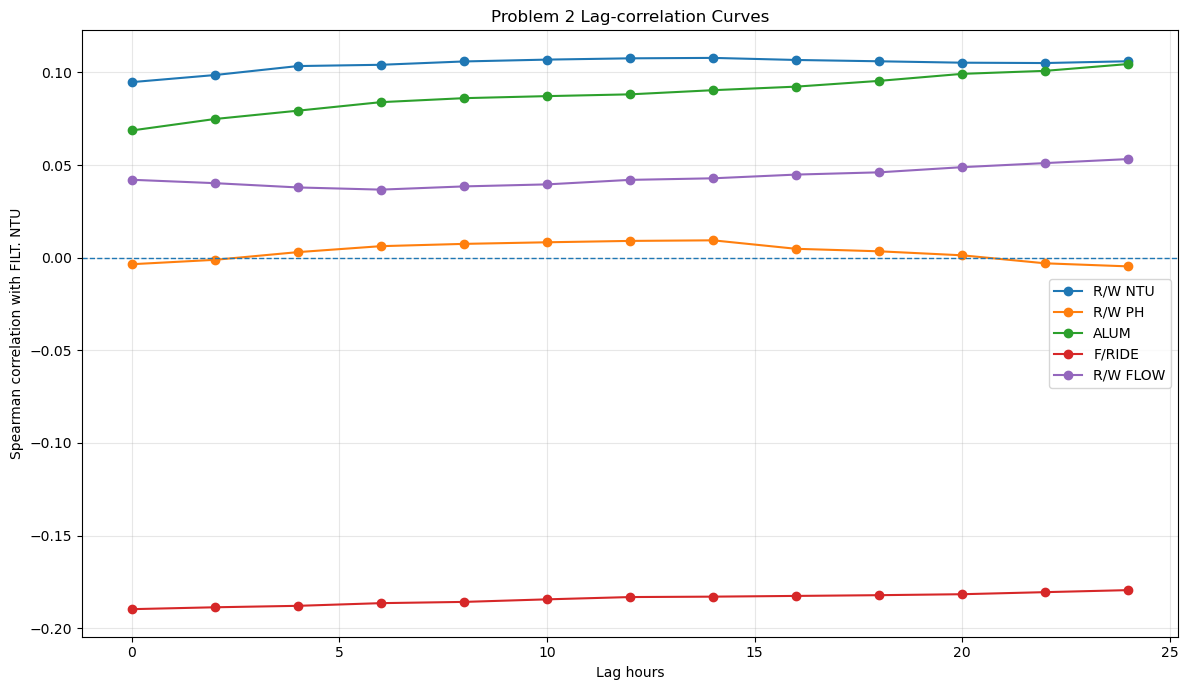

滞后相关性曲线已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_lag_correlation_curves.png


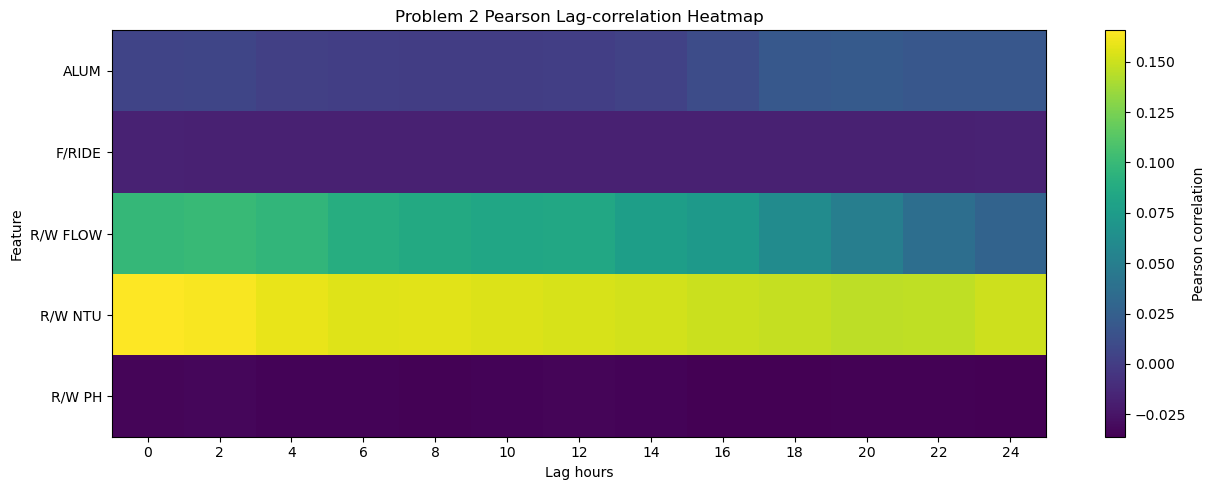

Pearson heatmap 已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_lag_pearson_heatmap.png


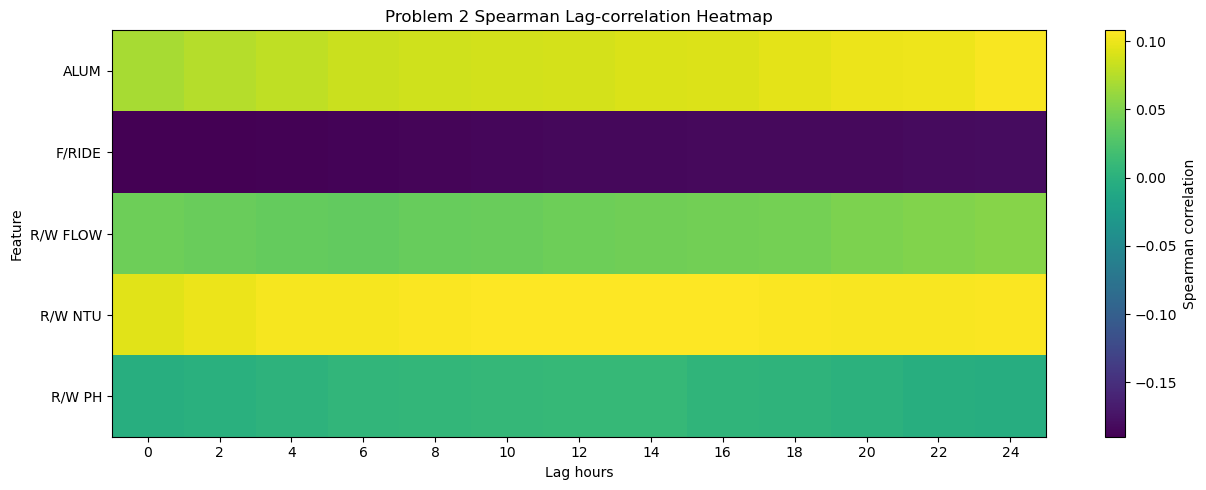

Spearman heatmap 已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_lag_spearman_heatmap.png


In [11]:
# 12.1 lag-correlation 曲线
plt.figure(figsize=(12, 7))

for feature in candidate_features:
    temp = lag_corr_df[lag_corr_df["base_feature"] == feature].copy()
    plt.plot(
        temp["lag_hours"],
        temp["spearman_corr"],
        marker="o",
        label=feature,
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lag hours")
plt.ylabel("Spearman correlation with FILT. NTU")
plt.title("Problem 2 Lag-correlation Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

curve_path = FIG_DIR / "problem2_lag_correlation_curves.png"
plt.savefig(curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("滞后相关性曲线已保存：", curve_path)


# 12.2 Pearson heatmap
pearson_pivot = lag_corr_df.pivot(
    index="base_feature",
    columns="lag_hours",
    values="pearson_corr",
)

plt.figure(figsize=(13, 5))
plt.imshow(pearson_pivot.values, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.yticks(range(len(pearson_pivot.index)), pearson_pivot.index)
plt.xticks(range(len(pearson_pivot.columns)), pearson_pivot.columns)
plt.xlabel("Lag hours")
plt.ylabel("Feature")
plt.title("Problem 2 Pearson Lag-correlation Heatmap")
plt.tight_layout()

pearson_heatmap_path = FIG_DIR / "problem2_lag_pearson_heatmap.png"
plt.savefig(pearson_heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Pearson heatmap 已保存：", pearson_heatmap_path)


# 12.3 Spearman heatmap
spearman_pivot = lag_corr_df.pivot(
    index="base_feature",
    columns="lag_hours",
    values="spearman_corr",
)

plt.figure(figsize=(13, 5))
plt.imshow(spearman_pivot.values, aspect="auto")
plt.colorbar(label="Spearman correlation")
plt.yticks(range(len(spearman_pivot.index)), spearman_pivot.index)
plt.xticks(range(len(spearman_pivot.columns)), spearman_pivot.columns)
plt.xlabel("Lag hours")
plt.ylabel("Feature")
plt.title("Problem 2 Spearman Lag-correlation Heatmap")
plt.tight_layout()

spearman_heatmap_path = FIG_DIR / "problem2_lag_spearman_heatmap.png"
plt.savefig(spearman_heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Spearman heatmap 已保存：", spearman_heatmap_path)


## 12. 构造 selected-lag 动态建模数据

根据上一节得到的最佳时滞参数，构造第二题动态模型的数据表。

数据形式：

```text
DATETIME
OP_DATE
target_FILT_NTU
R/W NTU_lag?
R/W PH_lag?
ALUM_lag?
F/RIDE_lag?
R/W FLOW_lag?
```

输出：

```text
outputs/problem2/problem2_selected_lag_model_data.xlsx
```


In [12]:
selected_lag_features = best_lag_summary["selected_lag_feature"].tolist()

p2_model_data = lag_df[["DATETIME", "OP_DATE", TARGET_NAME] + selected_lag_features].copy()

selected_data_path = OUTPUT_DIR / "problem2_selected_lag_model_data.xlsx"
p2_model_data.to_excel(selected_data_path, index=False)

print("第二题 selected-lag 建模数据已保存：", selected_data_path)
print("建模数据规模：", p2_model_data.shape)

display(p2_model_data.head(15))
display(best_lag_summary)


第二题 selected-lag 建模数据已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_selected_lag_model_data.xlsx
建模数据规模： (5460, 8)


,DATETIME,OP_DATE,target_FILT_NTU,F/RIDE_lag0,R/W NTU_lag7,ALUM_lag12,R/W FLOW_lag12,R/W PH_lag7
0,2025-01-01 07:00:00,2025-01-01,0.04,0.0,NaN,NaN,NaN,NaN
1,2025-01-01 09:00:00,2025-01-01,0.05,0.0,NaN,NaN,NaN,NaN
2,2025-01-01 11:00:00,2025-01-01,0.05,0.0,NaN,NaN,NaN,NaN
3,2025-01-01 13:00:00,2025-01-01,0.05,0.0,NaN,NaN,NaN,NaN
4,2025-01-01 15:00:00,2025-01-01,0.05,0.0,NaN,NaN,NaN,NaN
5,2025-01-01 17:00:00,2025-01-01,0.06,0.0,NaN,NaN,NaN,NaN
6,2025-01-01 19:00:00,2025-01-01,0.05,0.0,NaN,NaN,NaN,NaN
7,2025-01-01 21:00:00,2025-01-01,0.05,0.0,150.0,NaN,NaN,7.0
8,2025-01-01 23:00:00,2025-01-01,0.05,0.0,120.0,NaN,NaN,7.0
9,2025-01-02 01:00:00,2025-01-01,0.05,0.0,82.0,NaN,NaN,7.0


,base_feature,selected_lag,selected_lag_hours,selected_lag_feature,spearman_corr,abs_spearman_corr,pearson_corr,abs_pearson_corr,n_valid
3,F/RIDE,0,0,F/RIDE_lag0,-0.189740,0.189740,-0.017191,0.017191,4368
0,R/W NTU,7,14,R/W NTU_lag7,0.107842,0.107842,0.151865,0.151865,4361
2,ALUM,12,24,ALUM_lag12,0.104535,0.104535,0.018614,0.018614,2712
4,R/W FLOW,12,24,R/W FLOW_lag12,0.053229,0.053229,0.027927,0.027927,4356
1,R/W PH,7,14,R/W PH_lag7,0.009361,0.009361,-0.033946,0.033946,2717


## 13. 时间顺序划分训练集和测试集

动态时间序列模型不能随机划分，否则未来信息可能进入训练集。  
这里按时间顺序划分：

```text
前 80%：训练集
后 20%：测试集
```

输入特征缺失值不直接删除，而是在 pipeline 中使用训练集 median imputer 处理。


In [13]:
model_df = p2_model_data.dropna(subset=[TARGET_NAME, "DATETIME"]).copy()
model_df = model_df.sort_values("DATETIME").reset_index(drop=True)

split_idx = int(len(model_df) * TRAIN_RATIO)

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

feature_cols = selected_lag_features

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET_NAME].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET_NAME].copy()

print("训练集：", X_train.shape)
print("测试集：", X_test.shape)

print("训练集时间范围：", train_df["DATETIME"].min(), "至", train_df["DATETIME"].max())
print("测试集时间范围：", test_df["DATETIME"].min(), "至", test_df["DATETIME"].max())

missing_train = X_train.isna().mean().sort_values(ascending=False)
print("\n训练集输入特征缺失率：")
display(missing_train.to_frame("missing_rate"))


训练集： (4368, 5)
测试集： (1092, 5)
训练集时间范围： 2025-01-01 07:00:00 至 2025-12-31 05:00:00
测试集时间范围： 2025-12-31 07:00:00 至 2026-04-01 05:00:00

训练集输入特征缺失率：


,missing_rate
ALUM_lag12,0.379121
R/W PH_lag7,0.377976
R/W FLOW_lag12,0.002747
R/W NTU_lag7,0.001603
F/RIDE_lag0,0.000000


## 14. 建立动态数学模型

第二问要求建立动态数学模型并进行参数估计与验证。  
本 notebook 对比四类模型：

```text
1. Ridge Regression：基础动态线性模型，参数最容易解释
2. GAM：基于样条函数的加性非线性模型，可画变量影响曲线
3. Random Forest：非线性树模型，可输出变量重要性
4. XGBoost：boosting 树模型，可作为高性能对比模型
```

所有模型使用同一套预处理：

```text
Median Imputer
↓
StandardScaler
↓
Model
```

这样可以避免缺失值导致训练失败，并且避免使用测试集统计量造成数据泄漏。


In [14]:
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, feature_cols)
    ],
    remainder="drop"
)

models = {}

models["P2 Ridge"] = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=1.0))
])

models["P2 GAM"] = Pipeline([
    ("preprocess", preprocessor),
    ("model", Pipeline([
        ("spline", SplineTransformer(
            n_knots=5,
            degree=3,
            include_bias=False,
        )),
        ("ridge", Ridge(alpha=10.0))
    ]))
])

models["P2 Random Forest"] = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=N_ESTIMATORS_RF,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        max_features="sqrt",
        min_samples_leaf=2,
    ))
])

if XGBOOST_AVAILABLE:
    models["P2 XGBoost"] = Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBRegressor(
            n_estimators=N_ESTIMATORS_XGB,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ))
    ])
else:
    print("XGBoost 不可用，将跳过。错误信息：", XGBOOST_IMPORT_ERROR)

print("待训练模型：")
print(list(models.keys()))


待训练模型：
['P2 Ridge', 'P2 GAM', 'P2 Random Forest', 'P2 XGBoost']


## 15. 模型训练与验证

输出指标：

```text
MAE
RMSE
R²
MAPE
```

第二问原题明确要求给出 RMSE、R²，因此论文中应重点报告这两个指标。


In [15]:
def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100


result_records = []
prediction_records = []
fitted_models = {}

for model_name, pipe in models.items():
    print("\n" + "=" * 80)
    print("正在训练：", model_name)
    print("=" * 80)

    pipe.fit(X_train, y_train)
    fitted_models[model_name] = pipe

    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = safe_mape(y_test, y_pred)

    result_records.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_percent": mape,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "n_features": len(feature_cols),
    })

    pred_df = pd.DataFrame({
        "model": model_name,
        "DATETIME": test_df["DATETIME"].values,
        "OP_DATE": test_df["OP_DATE"].values,
        "actual_FILT_NTU": y_test.values,
        "predicted_FILT_NTU": y_pred,
        "residual": y_test.values - y_pred,
    })
    prediction_records.append(pred_df)

    print(f"MAE  = {mae:.6f}")
    print(f"RMSE = {rmse:.6f}")
    print(f"R²   = {r2:.6f}")
    print(f"MAPE = {mape:.3f}%")

results_df = pd.DataFrame(result_records).sort_values("RMSE")
test_predictions_df = pd.concat(prediction_records, ignore_index=True)

results_path = OUTPUT_DIR / "problem2_model_results.xlsx"
predictions_path = OUTPUT_DIR / "problem2_test_predictions.xlsx"

results_df.to_excel(results_path, index=False)
test_predictions_df.to_excel(predictions_path, index=False)

print("\n模型验证结果已保存：", results_path)
print("测试集预测结果已保存：", predictions_path)

display(results_df)



正在训练： P2 Ridge
MAE  = 0.211757
RMSE = 0.284445
R²   = -0.693178
MAPE = 319.638%

正在训练： P2 GAM
MAE  = 0.164891
RMSE = 0.267281
R²   = -0.495001
MAPE = 230.333%

正在训练： P2 Random Forest
MAE  = 0.094085
RMSE = 0.216995
R²   = 0.014622
MAPE = 114.832%

正在训练： P2 XGBoost
MAE  = 0.117039
RMSE = 0.245525
R²   = -0.261523
MAPE = 137.902%

模型验证结果已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_model_results.xlsx
测试集预测结果已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_test_predictions.xlsx


,model,MAE,RMSE,R2,MAPE_percent,n_train,n_test,n_features
2,P2 Random Forest,0.094085,0.216995,0.014622,114.831567,4368,1092,5
3,P2 XGBoost,0.117039,0.245525,-0.261523,137.901544,4368,1092,5
1,P2 GAM,0.164891,0.267281,-0.495001,230.333365,4368,1092,5
0,P2 Ridge,0.211757,0.284445,-0.693178,319.637773,4368,1092,5


## 16. Ridge 动态线性模型参数估计

Ridge 模型可以写为：

```text
FILT.NTU_t = β0 + β1 x1,t-τ1 + β2 x2,t-τ2 + ... + ε
```

由于模型输入经过标准化，这里的系数是标准化系数。  
系数绝对值越大，说明对应变量在动态线性模型中的影响越强。

输出：

```text
outputs/problem2/problem2_ridge_coefficients.xlsx
```


In [16]:
ridge_records = []

if "P2 Ridge" in fitted_models:
    ridge_pipe = fitted_models["P2 Ridge"]
    ridge_model = ridge_pipe.named_steps["model"]

    coef_values = ridge_model.coef_
    intercept_value = ridge_model.intercept_

    for feature, coef in zip(feature_cols, coef_values):
        ridge_records.append({
            "model": "P2 Ridge",
            "feature": feature,
            "standardized_coefficient": coef,
            "abs_standardized_coefficient": abs(coef),
            "direction": "positive" if coef > 0 else "negative" if coef < 0 else "zero",
            "intercept": intercept_value,
        })

ridge_coef_df = pd.DataFrame(ridge_records)
ridge_coef_df = ridge_coef_df.sort_values("abs_standardized_coefficient", ascending=False)

ridge_coef_path = OUTPUT_DIR / "problem2_ridge_coefficients.xlsx"
ridge_coef_df.to_excel(ridge_coef_path, index=False)

print("Ridge 参数估计结果已保存：", ridge_coef_path)
display(ridge_coef_df)


Ridge 参数估计结果已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_ridge_coefficients.xlsx


,model,feature,standardized_coefficient,abs_standardized_coefficient,direction,intercept
1,P2 Ridge,R/W NTU_lag7,0.104397,0.104397,positive,0.210499
2,P2 Ridge,ALUM_lag12,0.057286,0.057286,positive,0.210499
3,P2 Ridge,R/W FLOW_lag12,0.040295,0.040295,positive,0.210499
0,P2 Ridge,F/RIDE_lag0,-0.013779,0.013779,negative,0.210499
4,P2 Ridge,R/W PH_lag7,-0.010388,0.010388,negative,0.210499


## 17. 树模型特征重要性

Random Forest 和 XGBoost 可以直接输出 `feature_importances_`。  
这部分用于解释：

```text
1. 哪个输入变量最重要；
2. 哪个时滞阶数最关键；
3. 投药变量和原水变量对 FILT. NTU 的相对贡献。
```

输出：

```text
outputs/problem2/problem2_feature_importance.xlsx
```


In [17]:
importance_records = []

for model_name, pipe in fitted_models.items():
    model = pipe.named_steps["model"]

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_

        if len(importances) == len(feature_cols):
            for feature, importance in zip(feature_cols, importances):
                importance_records.append({
                    "model": model_name,
                    "feature": feature,
                    "importance": importance,
                })
        else:
            print(f"{model_name} 的 importance 数量与特征数不一致，跳过。")
    else:
        print(f"{model_name} 没有 feature_importances_，跳过。")

importance_df = pd.DataFrame(importance_records)

if len(importance_df) > 0:
    importance_df = importance_df.sort_values(["model", "importance"], ascending=[True, False])

    importance_path = OUTPUT_DIR / "problem2_feature_importance.xlsx"
    importance_df.to_excel(importance_path, index=False)

    print("特征重要性结果已保存：", importance_path)

    for model_name in importance_df["model"].unique():
        print("\n", model_name)
        display(importance_df[importance_df["model"] == model_name].head(20))
else:
    print("没有树模型特征重要性结果。")


P2 Ridge 没有 feature_importances_，跳过。
P2 GAM 没有 feature_importances_，跳过。
特征重要性结果已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_feature_importance.xlsx

 P2 Random Forest


,model,feature,importance
3,P2 Random Forest,R/W FLOW_lag12,0.469863
1,P2 Random Forest,R/W NTU_lag7,0.431548
0,P2 Random Forest,F/RIDE_lag0,0.072579
2,P2 Random Forest,ALUM_lag12,0.024392
4,P2 Random Forest,R/W PH_lag7,0.001617



 P2 XGBoost


,model,feature,importance
5,P2 XGBoost,F/RIDE_lag0,0.356528
6,P2 XGBoost,R/W NTU_lag7,0.241633
8,P2 XGBoost,R/W FLOW_lag12,0.236999
7,P2 XGBoost,ALUM_lag12,0.129372
9,P2 XGBoost,R/W PH_lag7,0.035468


## 18. GAM 变量影响曲线

GAM 的形式为：

```text
FILT.NTU_t = β0 + f1(x1) + f2(x2) + ... + ε
```

这里画出每个变量的部分影响曲线。  
横轴是变量原始取值，纵轴是相对于中位数工况的预测变化量。

输出：

```text
outputs/problem2/problem2_gam_partial_effect_curves_values.xlsx
outputs/problem2/figures/problem2_gam_partial_effect_curves.png
```


GAM 曲线数据已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_gam_partial_effect_curves_values.xlsx


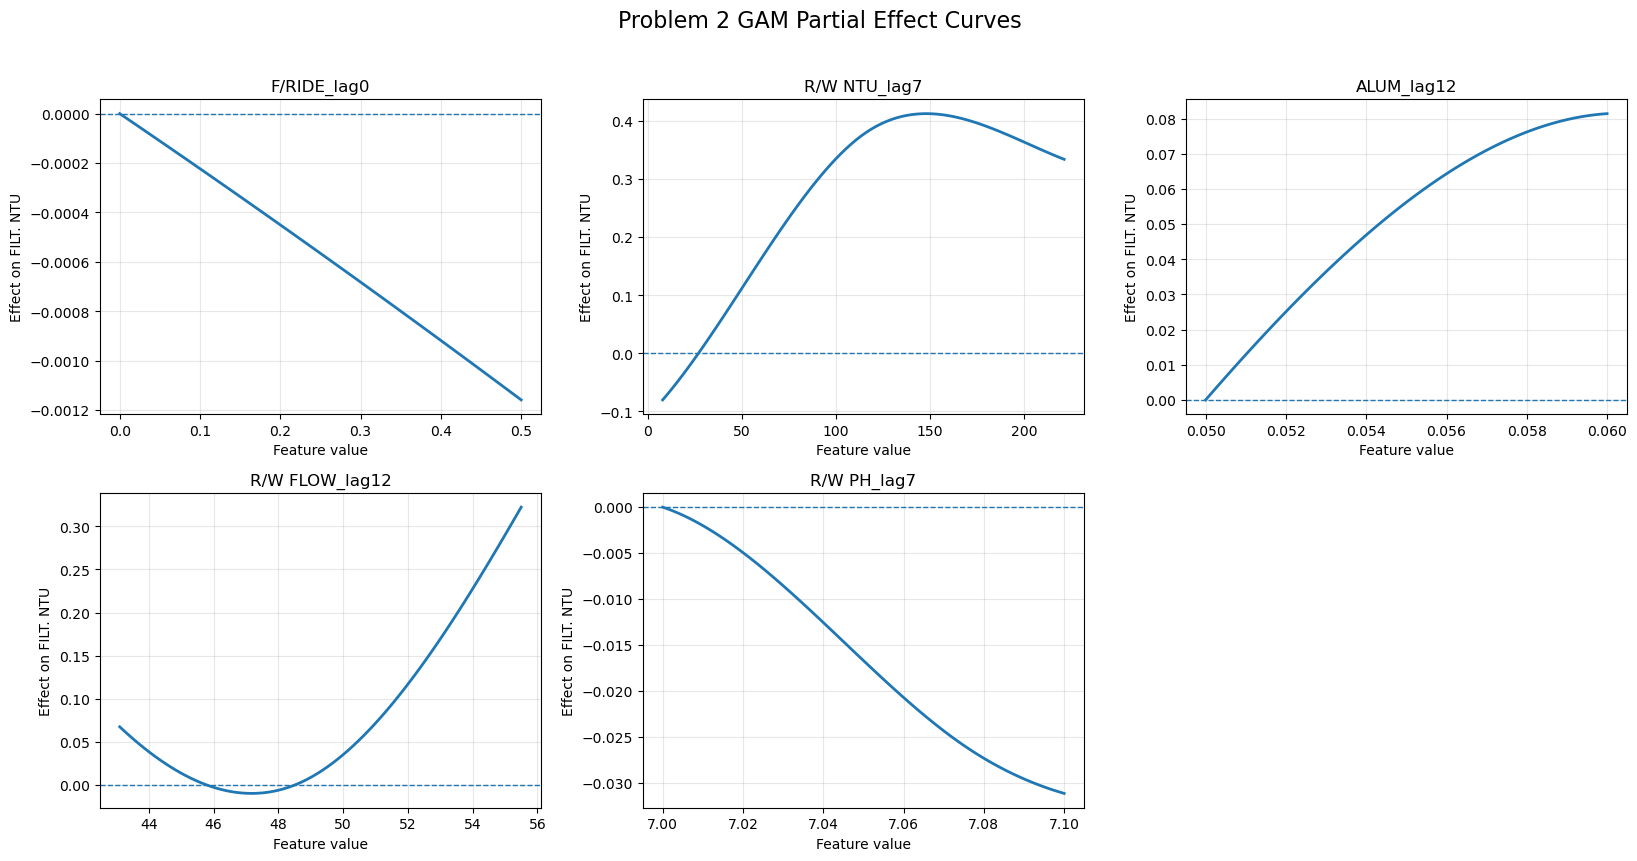

GAM 变量影响曲线已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_gam_partial_effect_curves.png


In [18]:
if "P2 GAM" in fitted_models:
    gam_pipe = fitted_models["P2 GAM"]

    X_reference = X_train.copy()

    # 中位数基准工况
    baseline_row = {}
    for col in feature_cols:
        baseline_row[col] = pd.to_numeric(X_reference[col], errors="coerce").median(skipna=True)

    baseline_df = pd.DataFrame([baseline_row])
    baseline_pred = gam_pipe.predict(baseline_df)[0]

    curve_records = []

    for feature in feature_cols:
        series = pd.to_numeric(X_reference[feature], errors="coerce").dropna()

        if len(series) < 10:
            continue

        q_low = series.quantile(0.01)
        q_high = series.quantile(0.99)

        if pd.isna(q_low) or pd.isna(q_high) or q_low == q_high:
            continue

        grid_values = np.linspace(q_low, q_high, 80)

        grid_df = pd.DataFrame([baseline_row] * len(grid_values))
        grid_df[feature] = grid_values

        preds = gam_pipe.predict(grid_df)
        effects = preds - baseline_pred

        for x_val, pred_val, eff_val in zip(grid_values, preds, effects):
            curve_records.append({
                "feature": feature,
                "x_value_original_scale": x_val,
                "predicted_FILT_NTU": pred_val,
                "effect_relative_to_baseline": eff_val,
                "baseline_predicted_FILT_NTU": baseline_pred,
            })

    gam_curve_df = pd.DataFrame(curve_records)

    gam_curve_values_path = OUTPUT_DIR / "problem2_gam_partial_effect_curves_values.xlsx"
    gam_curve_df.to_excel(gam_curve_values_path, index=False)

    print("GAM 曲线数据已保存：", gam_curve_values_path)

    features_available = gam_curve_df["feature"].unique().tolist()

    if len(features_available) > 0:
        n_cols = 3
        n_rows = math.ceil(len(features_available) / n_cols)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.2 * n_rows))
        axes = np.array(axes).reshape(-1)

        for ax, feature in zip(axes, features_available):
            temp = gam_curve_df[gam_curve_df["feature"] == feature].copy()

            ax.plot(
                temp["x_value_original_scale"],
                temp["effect_relative_to_baseline"],
                linewidth=2,
            )
            ax.axhline(0, linestyle="--", linewidth=1)
            ax.set_title(feature)
            ax.set_xlabel("Feature value")
            ax.set_ylabel("Effect on FILT. NTU")
            ax.grid(alpha=0.3)

        for ax in axes[len(features_available):]:
            ax.axis("off")

        fig.suptitle("Problem 2 GAM Partial Effect Curves", fontsize=16, y=1.02)
        plt.tight_layout()

        gam_curve_fig_path = FIG_DIR / "problem2_gam_partial_effect_curves.png"
        plt.savefig(gam_curve_fig_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("GAM 变量影响曲线已保存：", gam_curve_fig_path)

else:
    print("未找到 P2 GAM，跳过 GAM 曲线。")


## 19. 模型预测效果可视化

输出：

```text
1. 模型指标对比图
2. 测试集真实值与预测值时间序列图
3. Actual vs Predicted 散点图
4. 残差时间序列图
5. 树模型特征重要性图
```


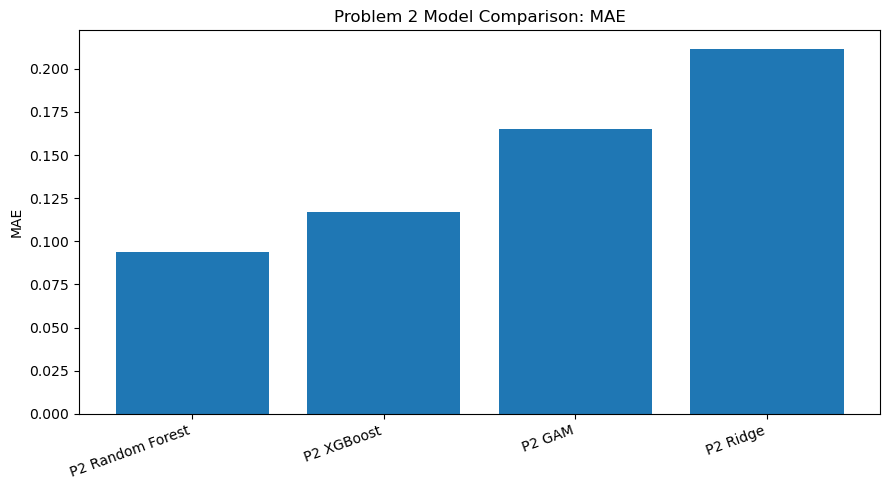

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_model_comparison_MAE.png


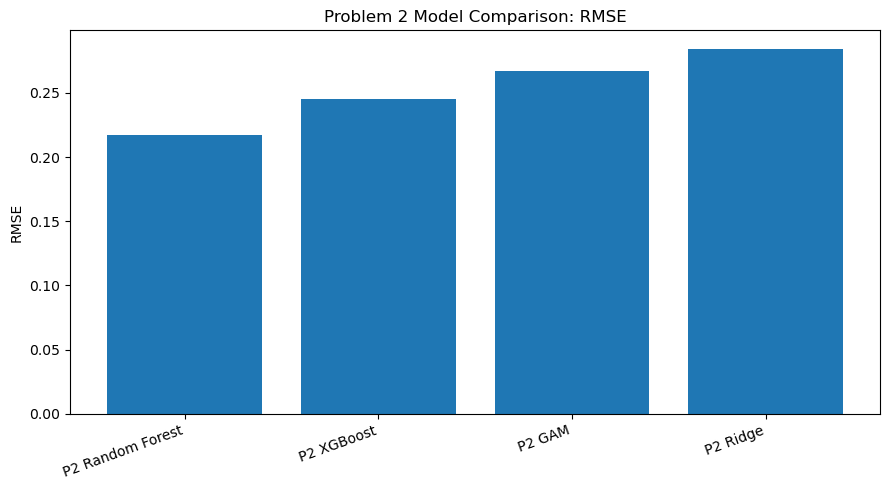

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_model_comparison_RMSE.png


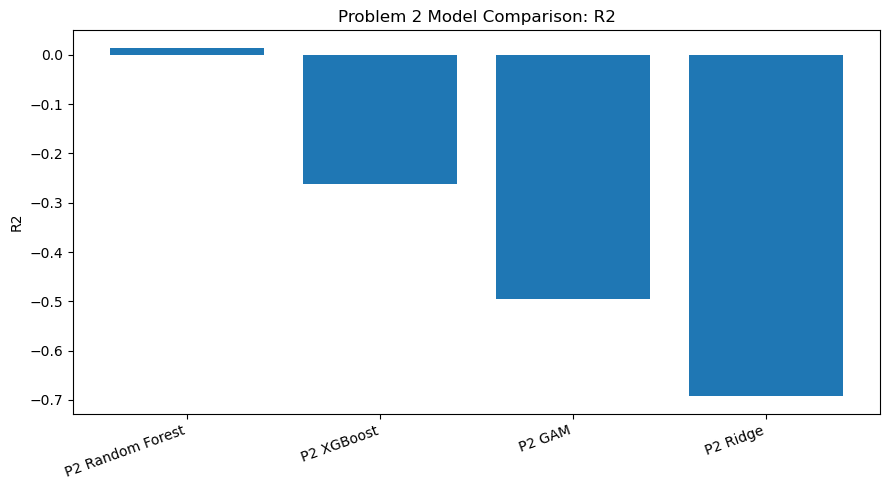

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_model_comparison_R2.png


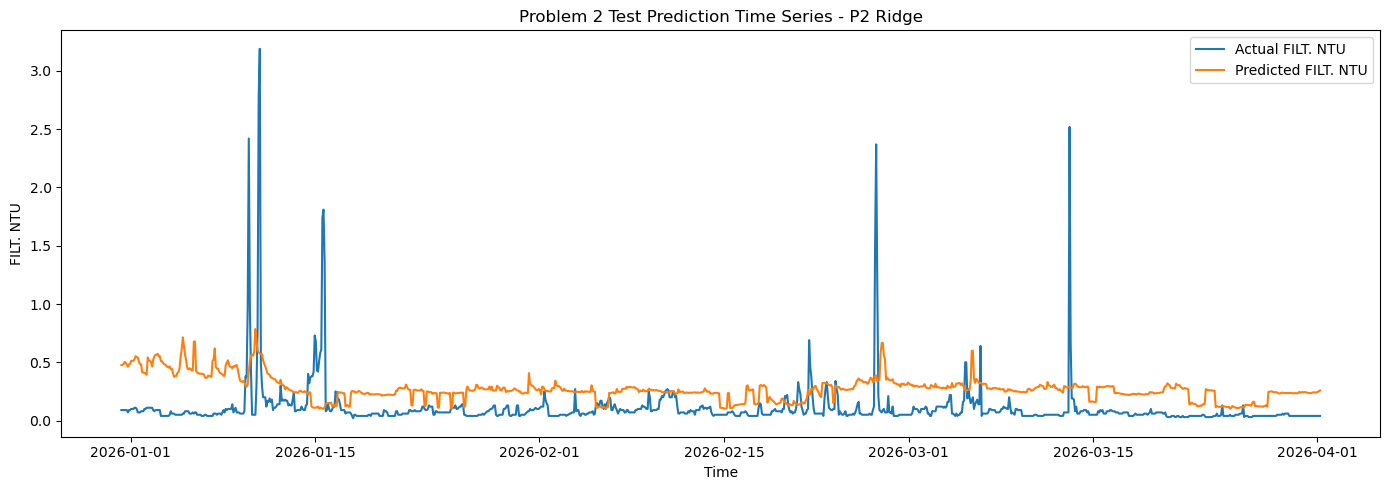

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_test_timeseries_P2_Ridge.png


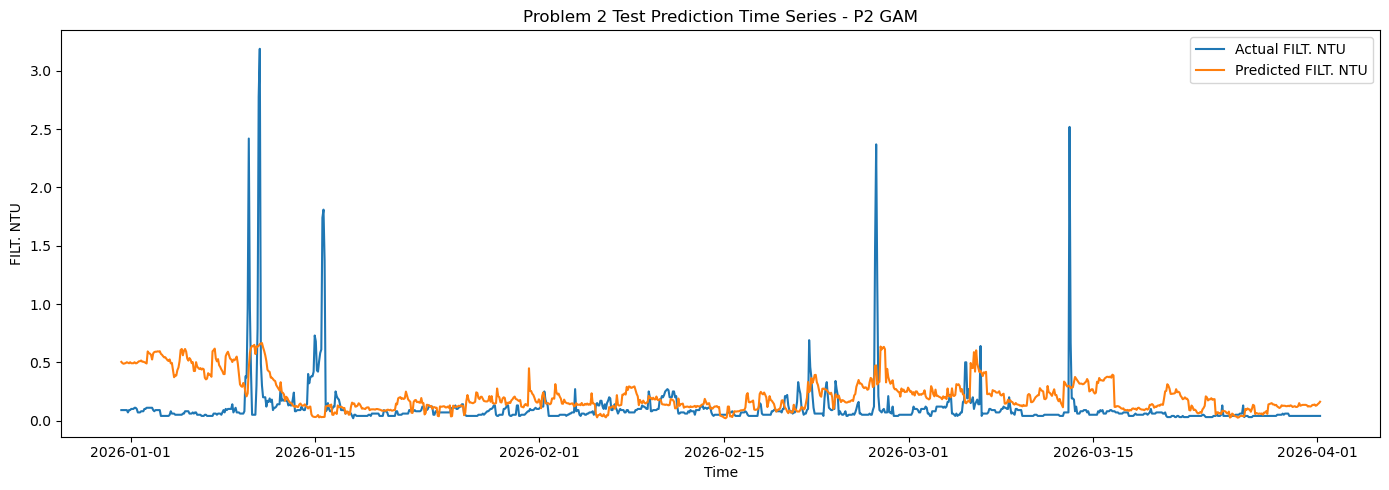

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_test_timeseries_P2_GAM.png


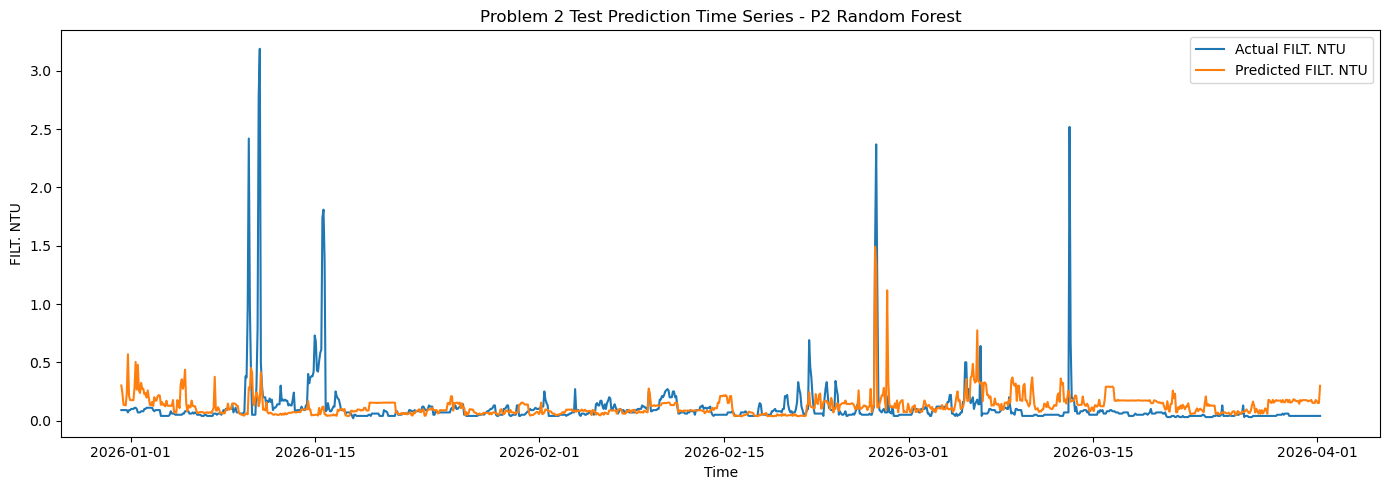

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_test_timeseries_P2_Random_Forest.png


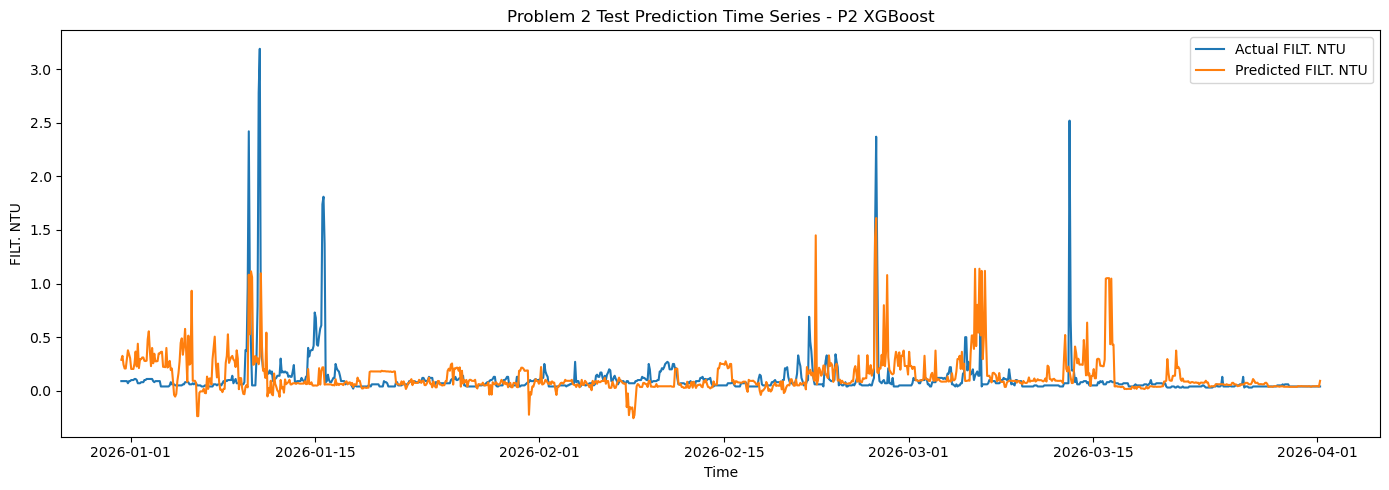

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_test_timeseries_P2_XGBoost.png


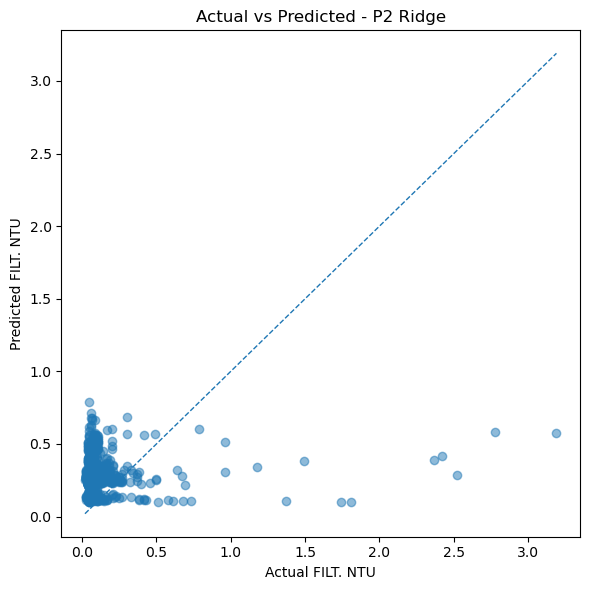

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_actual_vs_predicted_P2_Ridge.png


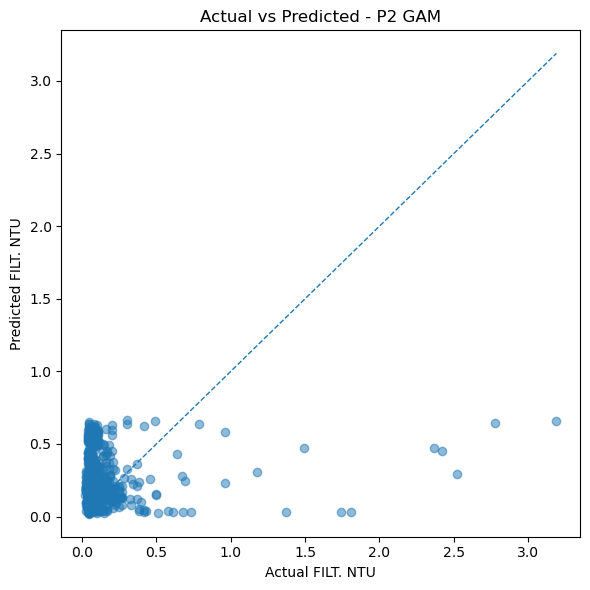

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_actual_vs_predicted_P2_GAM.png


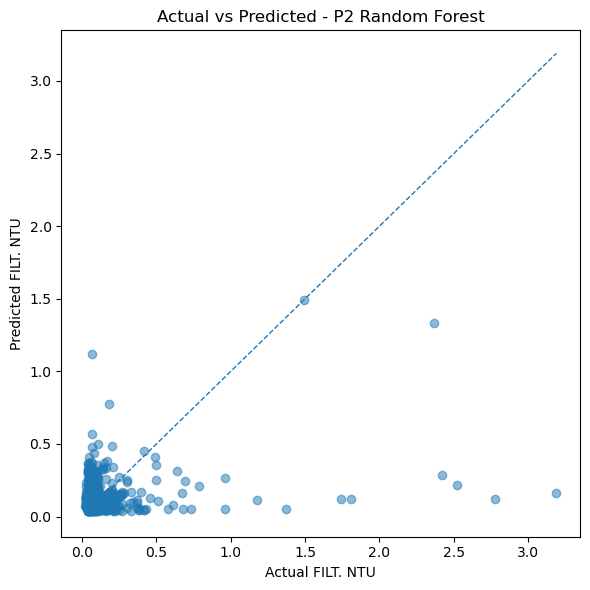

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_actual_vs_predicted_P2_Random_Forest.png


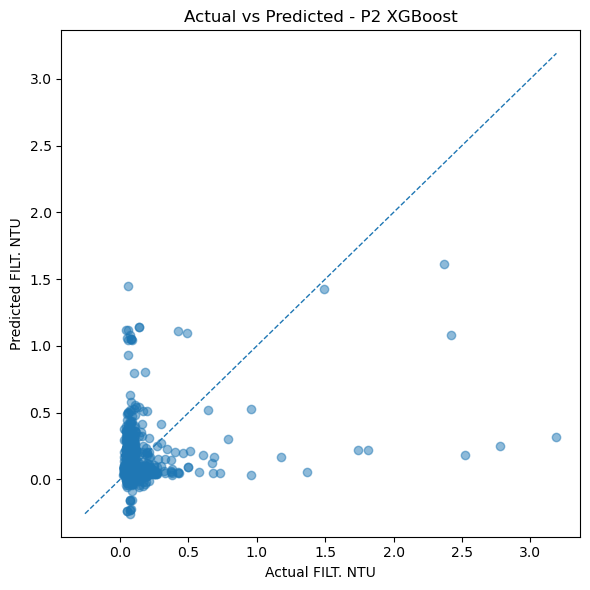

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_actual_vs_predicted_P2_XGBoost.png


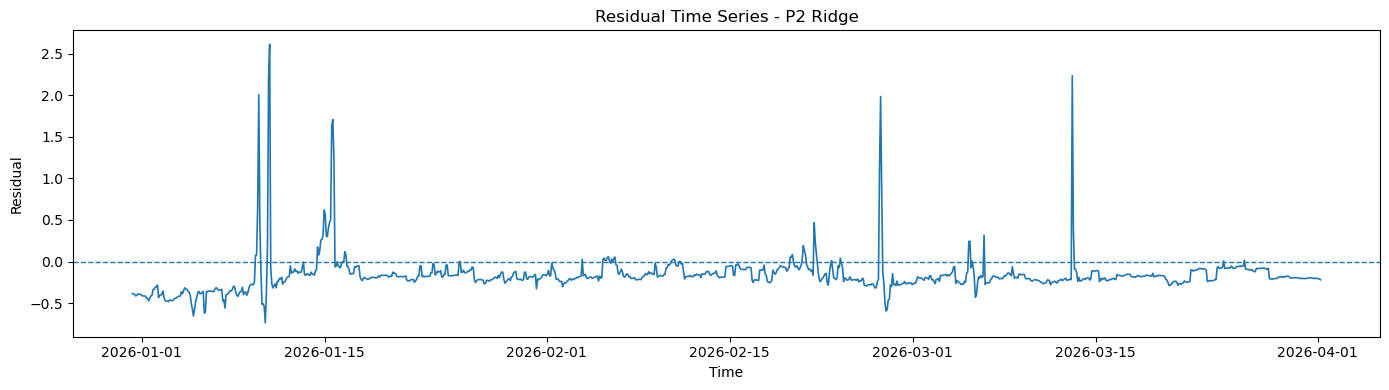

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_residual_timeseries_P2_Ridge.png


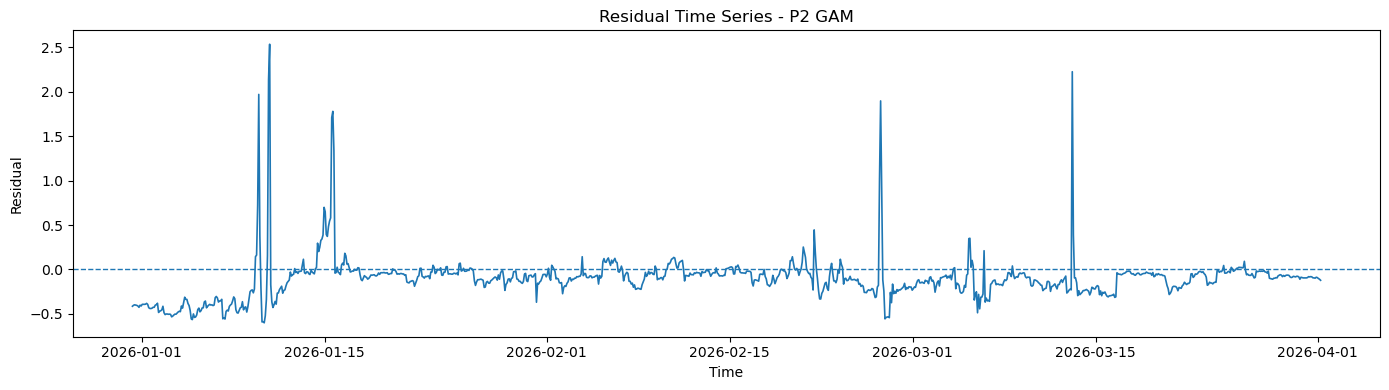

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_residual_timeseries_P2_GAM.png


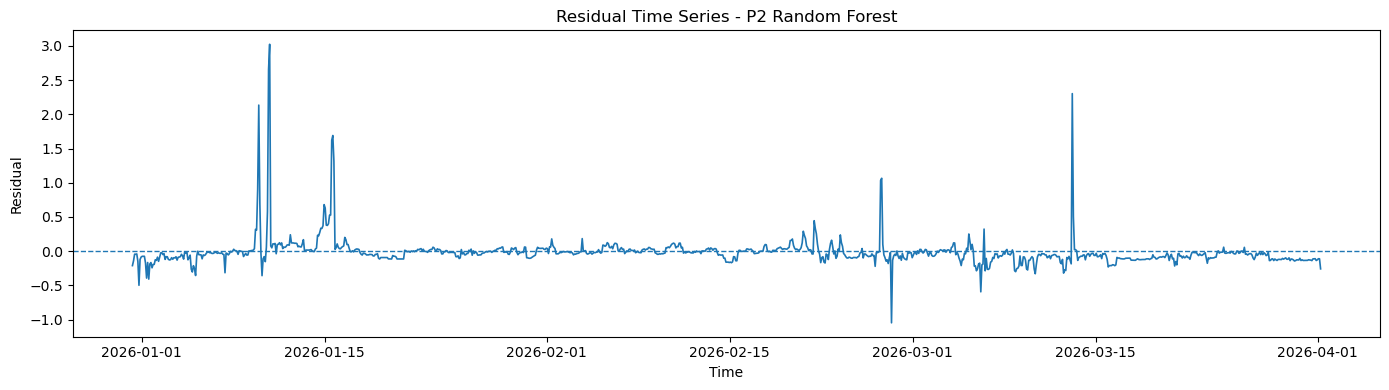

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_residual_timeseries_P2_Random_Forest.png


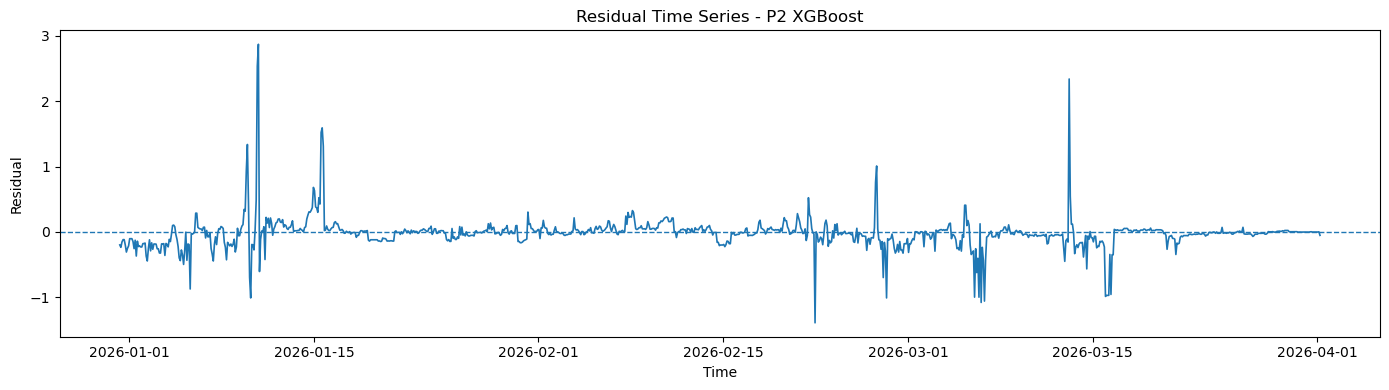

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_residual_timeseries_P2_XGBoost.png


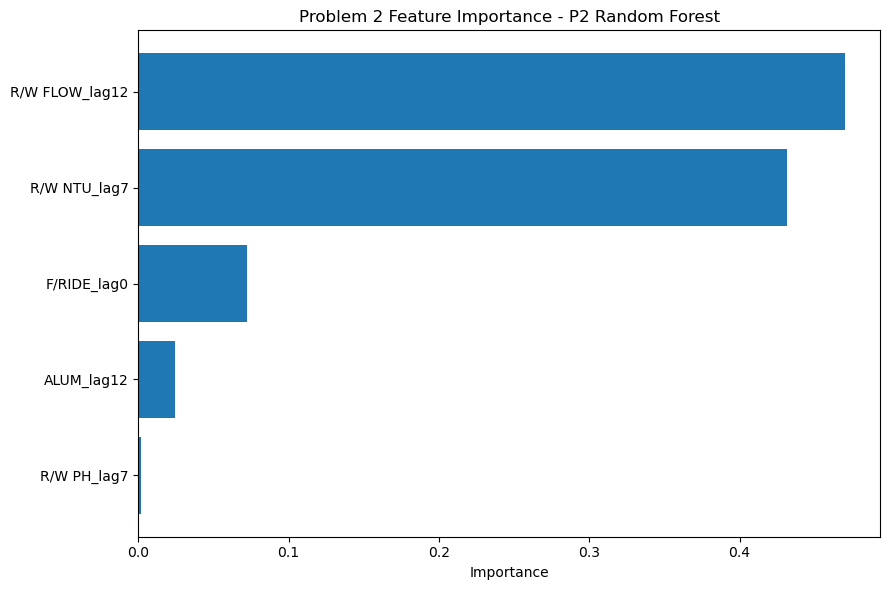

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_feature_importance_P2_Random_Forest.png


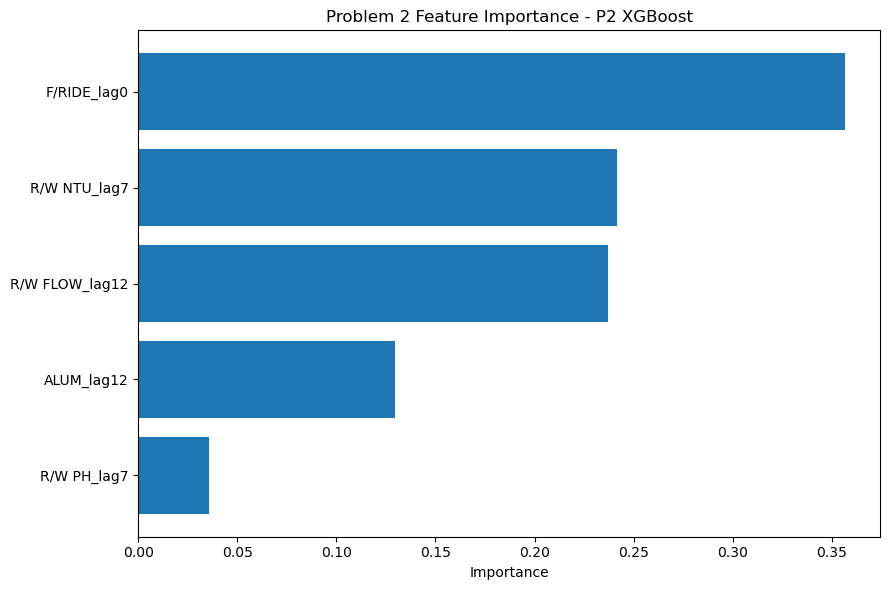

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\figures\problem2_feature_importance_P2_XGBoost.png


In [19]:
# 20.1 模型指标对比图
for metric in ["MAE", "RMSE", "R2"]:
    temp = results_df.sort_values(metric, ascending=(metric != "R2"))

    plt.figure(figsize=(9, 5))
    plt.bar(temp["model"], temp[metric])
    plt.title(f"Problem 2 Model Comparison: {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    fig_path = FIG_DIR / f"problem2_model_comparison_{metric}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("已保存：", fig_path)


# 20.2 测试集真实值与预测值时间序列
for model_name in test_predictions_df["model"].unique():
    temp = test_predictions_df[test_predictions_df["model"] == model_name].copy()

    plt.figure(figsize=(14, 5))
    plt.plot(temp["DATETIME"], temp["actual_FILT_NTU"], label="Actual FILT. NTU", linewidth=1.5)
    plt.plot(temp["DATETIME"], temp["predicted_FILT_NTU"], label="Predicted FILT. NTU", linewidth=1.5)
    plt.title(f"Problem 2 Test Prediction Time Series - {model_name}")
    plt.xlabel("Time")
    plt.ylabel("FILT. NTU")
    plt.legend()
    plt.tight_layout()

    safe_name = model_name.replace(" ", "_").replace("/", "_")
    fig_path = FIG_DIR / f"problem2_test_timeseries_{safe_name}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("已保存：", fig_path)


# 20.3 Actual vs Predicted 散点图
for model_name in test_predictions_df["model"].unique():
    temp = test_predictions_df[test_predictions_df["model"] == model_name].copy()

    plt.figure(figsize=(6, 6))
    plt.scatter(temp["actual_FILT_NTU"], temp["predicted_FILT_NTU"], alpha=0.5)

    min_val = min(temp["actual_FILT_NTU"].min(), temp["predicted_FILT_NTU"].min())
    max_val = max(temp["actual_FILT_NTU"].max(), temp["predicted_FILT_NTU"].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

    plt.title(f"Actual vs Predicted - {model_name}")
    plt.xlabel("Actual FILT. NTU")
    plt.ylabel("Predicted FILT. NTU")
    plt.tight_layout()

    safe_name = model_name.replace(" ", "_").replace("/", "_")
    fig_path = FIG_DIR / f"problem2_actual_vs_predicted_{safe_name}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("已保存：", fig_path)


# 20.4 残差时间序列图
for model_name in test_predictions_df["model"].unique():
    temp = test_predictions_df[test_predictions_df["model"] == model_name].copy()

    plt.figure(figsize=(14, 4))
    plt.plot(temp["DATETIME"], temp["residual"], linewidth=1.2)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Residual Time Series - {model_name}")
    plt.xlabel("Time")
    plt.ylabel("Residual")
    plt.tight_layout()

    safe_name = model_name.replace(" ", "_").replace("/", "_")
    fig_path = FIG_DIR / f"problem2_residual_timeseries_{safe_name}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("已保存：", fig_path)


# 20.5 特征重要性图
if "importance_df" in globals() and len(importance_df) > 0:
    for model_name in importance_df["model"].unique():
        temp = importance_df[importance_df["model"] == model_name].head(20).copy()
        temp = temp.sort_values("importance", ascending=True)

        plt.figure(figsize=(9, 6))
        plt.barh(temp["feature"], temp["importance"])
        plt.title(f"Problem 2 Feature Importance - {model_name}")
        plt.xlabel("Importance")
        plt.tight_layout()

        safe_name = model_name.replace(" ", "_").replace("/", "_")
        fig_path = FIG_DIR / f"problem2_feature_importance_{safe_name}.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("已保存：", fig_path)


## 20. 保存最终模型

这里将所有已经训练好的模型保存为 `.joblib` 文件，方便后续复现。


In [20]:
try:
    import joblib

    for model_name, pipe in fitted_models.items():
        safe_name = (
            model_name
            .replace(" ", "_")
            .replace("/", "_")
            .replace("-", "_")
        )
        model_path = MODEL_DIR / f"{safe_name}.joblib"
        joblib.dump(pipe, model_path)
        print("模型已保存：", model_path)

except Exception as e:
    print("模型保存失败：", e)


模型已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\models\P2_Ridge.joblib
模型已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\models\P2_GAM.joblib
模型已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\models\P2_Random_Forest.joblib
模型已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\models\P2_XGBoost.joblib


## 21. 第二题最终汇总

运行到这里后，第二题需要交付的核心文件已经全部生成。

重点查看：

```text
outputs/problem2/problem2_best_lag_summary.xlsx
outputs/problem2/problem2_selected_lag_model_data.xlsx
outputs/problem2/problem2_model_results.xlsx
outputs/problem2/problem2_ridge_coefficients.xlsx
outputs/problem2/problem2_feature_importance.xlsx
outputs/problem2/problem2_test_predictions.xlsx
outputs/problem2/figures/
```

论文中可以围绕三个问题展开：

```text
1. 每个输入变量的最佳时滞是多少？
2. 哪个动态模型的 RMSE 最低、R² 最高？
3. 哪些变量及其滞后项对 FILT. NTU 影响最大？
```


In [21]:
print("=" * 80)
print("问题二动态时滞模型已完成。")
print("=" * 80)

print("\n核心输出文件：")
print("1. 数据审计：", audit_path)
print("2. 完整候选 lag 数据：", all_lags_path)
print("3. 滞后相关性：", lag_corr_path)
print("4. 最佳时滞参数：", best_lag_path)
print("5. selected-lag 建模数据：", selected_data_path)
print("6. 模型验证结果：", results_path)
print("7. 测试集预测结果：", predictions_path)
print("8. Ridge 参数估计：", ridge_coef_path)

if "importance_path" in globals():
    print("9. 特征重要性：", importance_path)

if "gam_curve_values_path" in globals():
    print("10. GAM 曲线数据：", gam_curve_values_path)

print("图片目录：", FIG_DIR)

print("\n最佳时滞参数：")
display(best_lag_summary)

print("\n模型结果：")
display(results_df)

print("\nRMSE 最优模型：")
display(results_df.iloc[[0]])


问题二动态时滞模型已完成。

核心输出文件：
1. 数据审计： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_data_audit.xlsx
2. 完整候选 lag 数据： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_all_candidate_lags.xlsx
3. 滞后相关性： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_lag_correlation_all.xlsx
4. 最佳时滞参数： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_best_lag_summary.xlsx
5. selected-lag 建模数据： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_selected_lag_model_data.xlsx
6. 模型验证结果： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_model_results.xlsx
7. 测试集预测结果： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_test_predictions.xlsx
8. Ridge 参数估计： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_ridge_coefficients.xlsx
9. 特征重要性： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_feature_importance.xlsx
10. GAM 曲线数据： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_gam_partial_effect_curves_values.xlsx
图片目录： E:\桌面\亚太杯\2026-Asi

,base_feature,selected_lag,selected_lag_hours,selected_lag_feature,spearman_corr,abs_spearman_corr,pearson_corr,abs_pearson_corr,n_valid
3,F/RIDE,0,0,F/RIDE_lag0,-0.189740,0.189740,-0.017191,0.017191,4368
0,R/W NTU,7,14,R/W NTU_lag7,0.107842,0.107842,0.151865,0.151865,4361
2,ALUM,12,24,ALUM_lag12,0.104535,0.104535,0.018614,0.018614,2712
4,R/W FLOW,12,24,R/W FLOW_lag12,0.053229,0.053229,0.027927,0.027927,4356
1,R/W PH,7,14,R/W PH_lag7,0.009361,0.009361,-0.033946,0.033946,2717



模型结果：


,model,MAE,RMSE,R2,MAPE_percent,n_train,n_test,n_features
2,P2 Random Forest,0.094085,0.216995,0.014622,114.831567,4368,1092,5
3,P2 XGBoost,0.117039,0.245525,-0.261523,137.901544,4368,1092,5
1,P2 GAM,0.164891,0.267281,-0.495001,230.333365,4368,1092,5
0,P2 Ridge,0.211757,0.284445,-0.693178,319.637773,4368,1092,5



RMSE 最优模型：


,model,MAE,RMSE,R2,MAPE_percent,n_train,n_test,n_features
2,P2 Random Forest,0.094085,0.216995,0.014622,114.831567,4368,1092,5
